<center> <h1><b>PINYASURI FLIGHT METRICS ANALYSIS</b></h1></center>

This notebook computes flight performance metrics from raw telemetry data collected during drone missions.

# IMPORT LIBRARIES

In [15]:
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, asin
from pathlib import Path

RAW_CSV = Path("raw_flight_data(2).csv")
SUMMARY_CSV = Path("flight_metrics_summary.csv")

EARTH_RADIUS_M = 6371000  # meters

# HAVERSINE DISTANCE

In [16]:
def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * EARTH_RADIUS_M * asin(sqrt(a))

# LOAD DATA / CSV FILE

In [17]:
df = pd.read_csv(
    RAW_CSV,
    engine="python",      # tolerant parser
    on_bad_lines="skip"   # skip corrupted rows
)

df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"])

flights = df.groupby("flight_id")

results = []

# METRIC QUALITY THRESHOLDS

In [18]:
# =================================================
# METRIC QUALITY THRESHOLDS
# =================================================
THRESHOLDS = {
    "altitude_stability_index": {
        "good": 5.0,
        "acceptable": 10.0
    },
    "imu_vibration_rms_m_s2": {
        "good": 8.0,
        "acceptable": 12.0
    },
    "waypoint_accuracy_rms_m": {
        "good": 1.5,
        "acceptable": 3.0
    },
    "hover_position_jitter_rms_m": {
        "good": 1.0,
        "acceptable": 2.5
    },
    "avg_flight_duration_s": {
        "good": 60.0,
        "acceptable": 30.0
    }
}

# JUDGE METRIC

In [19]:
def judge_metric(value, good_thresh, acceptable_thresh, higher_is_better=False):
    if np.isnan(value):
        return "N/A"

    if higher_is_better:
        if value >= good_thresh:
            return "Good"
        elif value >= acceptable_thresh:
            return "Acceptable"
        else:
            return "Poor"
    else:
        if value <= good_thresh:
            return "Good"
        elif value <= acceptable_thresh:
            return "Acceptable"
        else:
            return "Poor"

# PER FLIGHT COMPUTATION

In [20]:
for flight_id, f in flights:

    # ---------------------------------------------
    # 1. Altitude / Attitude Stability
    # ---------------------------------------------
    roll_std = f["roll_deg"].std()
    pitch_std = f["pitch_deg"].std()
    yaw_std = f["yaw_deg"].std()
    alt_std = f["alt_m"].std()

    # ---------------------------------------------
    # 2. IMU Acceleration RMS
    # ---------------------------------------------
    accel_mag = np.sqrt(
        f["accel_x_m_s2"]**2 +
        f["accel_y_m_s2"]**2 +
        f["accel_z_m_s2"]**2
    )
    imu_rms = np.sqrt(np.mean(accel_mag**2))

    # ---------------------------------------------
    # 3. Waypoint Navigation Accuracy
    # ---------------------------------------------
    wp_valid = f[f["waypoint_index"] >= 0]

    if not wp_valid.empty:
        wp_valid = wp_valid.copy()
        wp_valid["horizontal_error_m"] = wp_valid.apply(
            lambda r: haversine(
                r["lat_deg"], r["lon_deg"],
                r["waypoint_lat_deg"], r["waypoint_lon_deg"]
            ),
            axis=1
        )
        wp_valid["vertical_error_m"] = abs(
            wp_valid["alt_m"] - wp_valid["waypoint_alt_m"]
        )

        waypoint_error_mean = wp_valid["horizontal_error_m"].mean()
        waypoint_error_rms = np.sqrt(
            np.mean(wp_valid["horizontal_error_m"]**2)
        )
    else:
        waypoint_error_mean = np.nan
        waypoint_error_rms = np.nan

    # ---------------------------------------------
    # 4. Hover Position Jitter
    # ---------------------------------------------
    hover = f[f["is_hovering"] == True]

    if not hover.empty:
        lat_mean = hover["lat_deg"].mean()
        lon_mean = hover["lon_deg"].mean()
        alt_mean = hover["alt_m"].mean()

        hover["pos_error_m"] = hover.apply(
            lambda r: haversine(
                r["lat_deg"], r["lon_deg"],
                lat_mean, lon_mean
            ),
            axis=1
        )

        hover_jitter_rms = np.sqrt(np.mean(hover["pos_error_m"]**2))
    else:
        hover_jitter_rms = np.nan

    # ---------------------------------------------
    # 5. Flight Endurance
    # ---------------------------------------------
    flight_time_s = (
        f["timestamp_utc"].iloc[-1] -
        f["timestamp_utc"].iloc[0]
    ).total_seconds()

    avg_current = f["battery_current_A"].mean()
    avg_voltage = f["battery_voltage_V"].mean()

    # ---------------------------------------------
    # Save result
    # ---------------------------------------------
    results.append({
        "flight_id": flight_id,
        "duration_s": round(flight_time_s, 1),

        # Stability
        "roll_std_deg": round(roll_std, 3),
        "pitch_std_deg": round(pitch_std, 3),
        "yaw_std_deg": round(yaw_std, 3),
        "altitude_std_m": round(alt_std, 3),

        # IMU
        "imu_accel_rms_m_s2": round(imu_rms, 3),

        # Waypoints
        "wp_error_mean_m": round(waypoint_error_mean, 2),
        "wp_error_rms_m": round(waypoint_error_rms, 2),

        # Hover
        "hover_jitter_rms_m": round(hover_jitter_rms, 2),

        # Endurance
        "avg_current_A": round(avg_current, 2),
        "avg_voltage_V": round(avg_voltage, 2)
    })

C:\Users\Purca\AppData\Local\Temp\ipykernel_1572\3271564310.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hover["pos_error_m"] = hover.apply(
C:\Users\Purca\AppData\Local\Temp\ipykernel_1572\3271564310.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hover["pos_error_m"] = hover.apply(
C:\Users\Purca\AppData\Local\Temp\ipykernel_1572\3271564310.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

# SAVE SUMMARY

In [21]:
summary_df = pd.DataFrame(results)

# OVERALL (ONE VALUE) METRICS + JUDGMENT

In [22]:
overall_metrics = {}

# ---- Altitude Stability ----
alt_stability = np.nanmean([
    summary_df["roll_std_deg"].mean(),
    summary_df["pitch_std_deg"].mean(),
    summary_df["yaw_std_deg"].mean(),
    summary_df["altitude_std_m"].mean()
])

overall_metrics["altitude_stability_index"] = round(alt_stability, 3)
overall_metrics["altitude_stability_rating"] = judge_metric(
    alt_stability,
    THRESHOLDS["altitude_stability_index"]["good"],
    THRESHOLDS["altitude_stability_index"]["acceptable"]
)

# ---- IMU Vibration ----
imu_rms = summary_df["imu_accel_rms_m_s2"].mean()

overall_metrics["imu_vibration_rms_m_s2"] = round(imu_rms, 3)
overall_metrics["imu_vibration_rating"] = judge_metric(
    imu_rms,
    THRESHOLDS["imu_vibration_rms_m_s2"]["good"],
    THRESHOLDS["imu_vibration_rms_m_s2"]["acceptable"]
)

# ---- Waypoint Accuracy ----
wp_rms = summary_df["wp_error_rms_m"].dropna().mean()

overall_metrics["waypoint_accuracy_rms_m"] = round(wp_rms, 2)
overall_metrics["waypoint_accuracy_rating"] = judge_metric(
    wp_rms,
    THRESHOLDS["waypoint_accuracy_rms_m"]["good"],
    THRESHOLDS["waypoint_accuracy_rms_m"]["acceptable"]
)

# ---- Hover Jitter ----
hover_rms = summary_df["hover_jitter_rms_m"].dropna().mean()

overall_metrics["hover_position_jitter_rms_m"] = round(hover_rms, 2)
overall_metrics["hover_position_jitter_rating"] = judge_metric(
    hover_rms,
    THRESHOLDS["hover_position_jitter_rms_m"]["good"],
    THRESHOLDS["hover_position_jitter_rms_m"]["acceptable"]
)

# ---- Flight Endurance ----
avg_duration = summary_df["duration_s"].mean()

overall_metrics["avg_flight_duration_s"] = round(avg_duration, 1)
overall_metrics["flight_endurance_rating"] = judge_metric(
    avg_duration,
    THRESHOLDS["avg_flight_duration_s"]["good"],
    THRESHOLDS["avg_flight_duration_s"]["acceptable"],
    higher_is_better=True
)

# ---- Save ----
overall_df = pd.DataFrame(overall_metrics, index=["overall"])
overall_df.to_csv("overall_metrics.csv")

print("✓ Overall metrics WITH quality ratings saved")

✓ Overall metrics WITH quality ratings saved


# VISUALIZATION PER METRICS

# 1. Altitude Stability Visualization

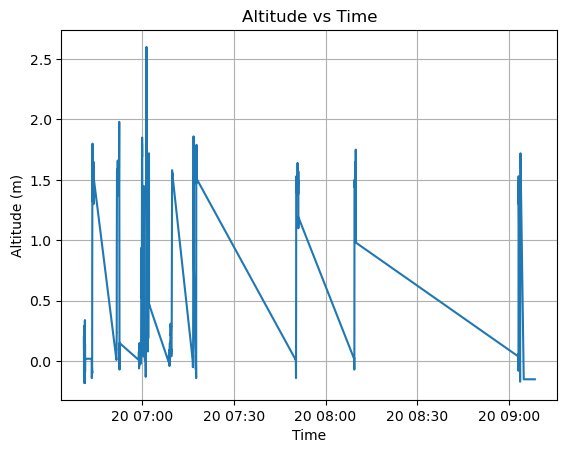

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["timestamp_utc"], df["alt_m"])
plt.xlabel("Time")
plt.ylabel("Altitude (m)")
plt.title("Altitude vs Time")
plt.grid(True)
plt.show()

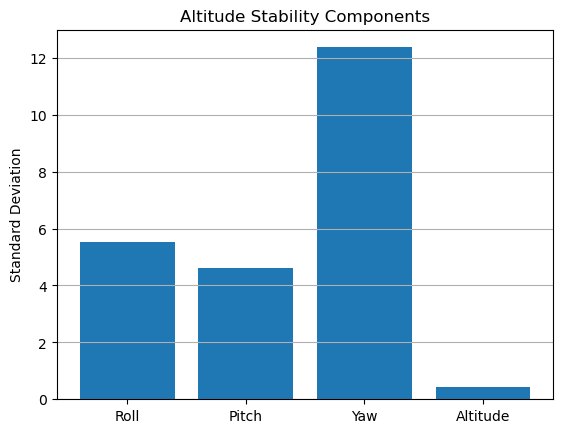

In [11]:
labels = ["Roll", "Pitch", "Yaw", "Altitude"]
values = [
    summary_df["roll_std_deg"].mean(),
    summary_df["pitch_std_deg"].mean(),
    summary_df["yaw_std_deg"].mean(),
    summary_df["altitude_std_m"].mean()
]

plt.figure()
plt.bar(labels, values)
plt.ylabel("Standard Deviation")
plt.title("Altitude Stability Components")
plt.grid(axis="y")
plt.show()

# 2. IMU Acceleration RMS Visualization

In [13]:
plt.figure()
plt.plot(df["timestamp_utc"], df["accel_x"], label="Accel X")
plt.plot(df["timestamp_utc"], df["accel_y"], label="Accel Y")
plt.plot(df["timestamp_utc"], df["accel_z"], label="Accel Z")
plt.xlabel("Time")
plt.ylabel("Acceleration (m/s²)")
plt.title("IMU Acceleration vs Time")
plt.legend()
plt.grid(True)
plt.show()

KeyError: 'accel_x'

<Figure size 640x480 with 0 Axes>

In [12]:
rms_x = np.sqrt(np.nanmean(df["accel_x"]**2))
rms_y = np.sqrt(np.nanmean(df["accel_y"]**2))
rms_z = np.sqrt(np.nanmean(df["accel_z"]**2))

plt.figure()
plt.bar(["X", "Y", "Z"], [rms_x, rms_y, rms_z])
plt.ylabel("RMS Acceleration (m/s²)")
plt.title("IMU Acceleration RMS")
plt.grid(axis="y")
plt.show()

KeyError: 'accel_x'

# 3. Waypoint Navigation Accuracy

In [ ]:
plt.figure()
plt.plot(df["longitude"], df["latitude"], label="Flight Path")
plt.scatter(
    df["wp_longitude"],
    df["wp_latitude"],
    marker="x",
    label="Waypoints"
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Waypoint Navigation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.figure()
plt.hist(df["waypoint_error_m"].dropna(), bins=30)
plt.xlabel("Position Error (m)")
plt.ylabel("Frequency")
plt.title("Waypoint Error Distribution")
plt.grid(True)
plt.show()

# 4. Hover Position Jitter

In [ ]:
# XY Scatter During Hover

hover_df = df[df["flight_mode"] == "HOVER"]

plt.figure()
plt.scatter(
    hover_df["longitude"],
    hover_df["latitude"],
    s=5
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Hover Position Jitter")
plt.grid(True)
plt.show()

In [ ]:
# Distance-from-Mean Jitter

mean_lat = hover_df["latitude"].mean()
mean_lon = hover_df["longitude"].mean()

hover_df["jitter_m"] = hover_df.apply(
    lambda r: haversine(
        r["latitude"], r["longitude"],
        mean_lat, mean_lon
    ),
    axis=1
)

plt.figure()
plt.hist(hover_df["jitter_m"], bins=30)
plt.xlabel("Jitter Distance (m)")
plt.ylabel("Frequency")
plt.title("Hover Position Jitter Distribution")
plt.grid(True)
plt.show()

# 5. Flight Endurance / Power Performance

In [ ]:
# Battery Voltage vs Time

plt.figure()
plt.plot(df["timestamp_utc"], df["battery_voltage"])
plt.xlabel("Time")
plt.ylabel("Voltage (V)")
plt.title("Battery Voltage vs Time")
plt.grid(True)
plt.show()

In [ ]:
# Current Draw vs Time

plt.figure()
plt.plot(df["timestamp_utc"], df["battery_current"])
plt.xlabel("Time")
plt.ylabel("Current (A)")
plt.title("Battery Current Draw vs Time")
plt.grid(True)
plt.show()

In [ ]:
# Power Consumption

power = df["battery_voltage"] * df["battery_current"]

plt.figure()
plt.plot(df["timestamp_utc"], power)
plt.xlabel("Time")
plt.ylabel("Power (W)")
plt.title("Power Consumption vs Time")
plt.grid(True)
plt.show()

# OVERALL METRICS SUMMARY

In [ ]:
overall_df.T.plot(kind="bar", legend=False)
plt.title("Overall Flight Performance Metrics")
plt.grid(axis="y")
plt.show()